In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!curl -o Film_Permits.csv "https://data.cityofnewyork.us/resource/tg4x-b46p.csv?\$limit=50000"

df = pd.read_csv("Film_Permits.csv")
df.head()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 6175k    0 6175k    0     0  6338k      0 --:--:-- --:--:-- --:--:-- 6334k


,eventid,eventtype,startdatetime,enddatetime,enteredon,eventagency,parkingheld,borough,communityboard_s,policeprecinct_s,category,subcategoryname,country,zipcode_s
0,889630,Rigging Permit,2025-09-15T06:00:00.000,2025-09-15T17:00:00.000,2025-09-12T16:33:12.000,Mayor's Office of Media & Entertainment,NORTH HENRY STREET between MESEROLE AVENUE and...,Brooklyn,"1,","94,",Television,Episodic series,United States of America,"11222,"
1,889599,Shooting Permit,2025-09-16T02:00:00.000,2025-09-16T19:00:00.000,2025-09-12T15:07:18.000,Mayor's Office of Media & Entertainment,SMITH STREET between HALLECK STREET and BAY ST...,Brooklyn,"6,","76,",Still Photography,Not Applicable,United States of America,"11231,"
2,889592,Shooting Permit,2025-09-16T05:00:00.000,2025-09-16T20:00:00.000,2025-09-12T14:51:21.000,Mayor's Office of Media & Entertainment,BEAVER STREET between NEW STREET and BROAD STREET,Manhattan,"1,","1,",WEB,Not Applicable,United States of America,"10004, 10005,"
3,889500,Theater Load in and Load Outs,2025-09-14T09:00:00.000,2025-09-15T03:00:00.000,2025-09-12T09:29:18.000,Mayor's Office of Media & Entertainment,EAST 23 STREET between LEXINGTON AVENUE and ...,Manhattan,"5,","13,",Theater,Theater,United States of America,"10010,"
4,889498,Shooting Permit,2025-09-16T06:00:00.000,2025-09-16T20:00:00.000,2025-09-12T09:11:28.000,Mayor's Office of Media & Entertainment,KING STREET between GREENWICH STREET and HUDSO...,Manhattan,"2,","1,",Commercial,Commercial,United States of America,"10014,"


In [24]:
df['startdatetime'] = pd.to_datetime(df['startdatetime'])
# Check the earliest and latest date in the dataset
print("Earliest Date:", df['startdatetime'].min())
print("Latest Date:", df['startdatetime'].max())

Earliest Date: 2023-01-01 04:00:00
Latest Date: 2025-09-17 12:01:00


# 1) Is there a seasonal trend in filming activities in New York City? Specifically, which months generally see the highest volume of film permits issued?

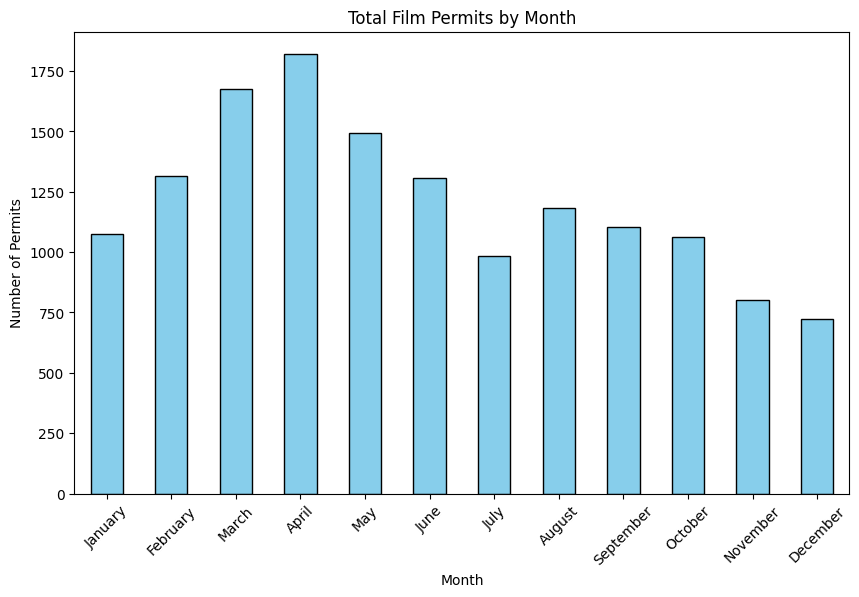

In [25]:


# Extract the month name/number to group by month
df['Month'] = df['startdatetime'].dt.month_name()

# Count permits per month
monthly_counts = df['Month'].value_counts()

# Reorder indices for proper calendar order
calendar_order = ['January', 'February', 'March', 'April', 'May', 'June',
                  'July', 'August', 'September', 'October', 'November', 'December']
monthly_counts = monthly_counts.reindex(calendar_order)

# Plot the trend
plt.figure(figsize=(10,6))
monthly_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Total Film Permits by Month')
plt.xlabel('Month')
plt.ylabel('Number of Permits')
plt.xticks(rotation=45)
plt.show()

The data reveals a very clear seasonal trend. Filming activity appears to peak heavily in the Spring, with April being the busiest month, followed closely by March and May. This suggests production crews prefer the mild weather of spring before the intense summer heat sets in. Interestingly, we see a dip in July, probaly due to high temperatures or mid summer hiatuses, before a smaller rise in August. As expected, activity tapers off significantly in November and December, likely due to the holiday season and colder weather making outdoor shoots more difficult.

# 2) How does the type of media production differ across the five boroughs? Does Manhattan dominate all categories, or do other boroughs see significant activity for specific types?

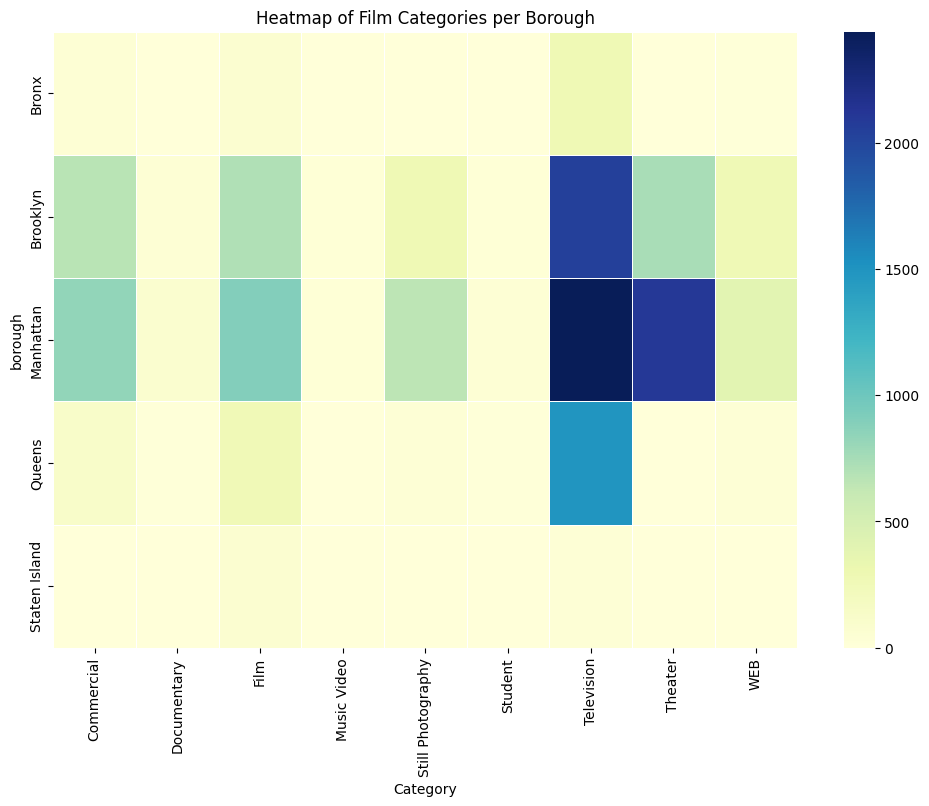

category       Television  Film  Commercial  Theater
borough                                             
Bronx                 283    69          47        4
Brooklyn             2048   713         670      736
Manhattan            2439   896         834     2102
Queens               1492   260         126        0
Staten Island          37    70           9        0


In [26]:
# Group by Borough and Category to see the breakdown
borough_category = df.groupby(['borough', 'category']).size().unstack(fill_value=0)

# Display the top categories to keep the chart readable

plt.figure(figsize=(12,8))
sns.heatmap(borough_category, annot=False, cmap="YlGnBu", linewidths=.5)
plt.title('Heatmap of Film Categories per Borough')
plt.xlabel('Category')
plt.ylabel('borough')
plt.show()

# Show the raw numbers for clarity
print(borough_category[['Television', 'Film', 'Commercial', 'Theater']])

Looking at this heatmap really shows a split between Manhattan and Brooklyn. I expected Manhattan to be the top spot overall, and it is definitely the leader for Theater, likely because of the Broadway district. It also has the most permits for Commercials and Film. But when you look at Television, Brooklyn is a huge competitor. It has over 2,000 permits which is nearly the same as Manhattan. Queens is also strong in TV production with around 1,500 permits, which I assume is due to the major studios located there like Silvercup. It seems like while Manhattan is the go-to spot for movies, a ton of TV work is actually happening in the outer boroughs. By comparison, the Bronx and Staten Island see very little activity compared to the big three.

# 3) What is the ratio of "Student Film" permits compared to major "Feature Film" permits?

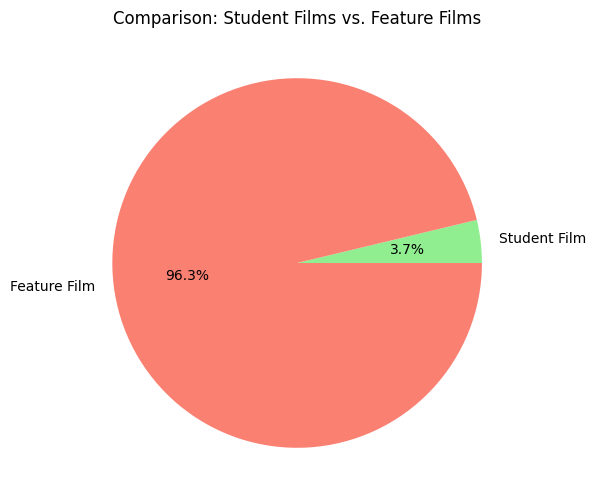

Total Student Films: 68
Total Feature Films: 1746


In [27]:
# Filtering the dataframe for Student Films
student_films = df[df['subcategoryname'] == 'Student Film']

# Filtering the dataframe for Feature Films
feature_films = df[df['subcategoryname'] == 'Feature']

# Calculate counts
student_count = len(student_films)
feature_count = len(feature_films)

# Create a simple comparison dataframe
comparison_df = pd.DataFrame({
    'Type': ['Student Film', 'Feature Film'],
    'Count': [student_count, feature_count]
})

# Plot the comparison
plt.figure(figsize=(6,6))
plt.pie(comparison_df['Count'], labels=comparison_df['Type'], autopct='%1.1f%%', colors=['lightgreen', 'salmon'])
plt.title('Comparison: Student Films vs. Feature Films')
plt.show()

print(f"Total Student Films: {student_count}")
print(f"Total Feature Films: {feature_count}")

I honestly expected the number of student films to be a bit higher given how many film schools are in New York, but the data shows a massive gap. Feature films make up over 96 percent of this comparison, with 1,746 permits versus just 68 for student projects. This makes sense when you consider the resources involved. Feature films have the budget and staff to handle the complex permitting process required for shooting on city streets, whereas student productions might be sticking to private locations or campuses where they do not need official city permits.